<a href="https://colab.research.google.com/github/AlaguKannanMl/Seasonal-Agriculture-Performance-Analysis/blob/main/Seasonal_Agriculture_Performance_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import glob

files = glob.glob("*.xlsx")
print(files)

['seasonal_agriculture_performance_dataset.xlsx']


In [3]:
file_path = files[0]
df = pd.read_excel(file_path)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Shape: (4000, 28)


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [4]:
print("Column Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

Column Names:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-nul

In [5]:
df = df.drop_duplicates()

numeric_cols = df.select_dtypes(include=['number']).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

print("Data cleaning completed!")
print("Final Shape:", df.shape)

print("\nRemaining Missing Values:")
print(df.isnull().sum().sum())

Data cleaning completed!
Final Shape: (4000, 28)

Remaining Missing Values:
0


In [6]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nStatistical Summary:")
display(df.describe(include="all").T)

Dataset Shape: (4000, 28)

Column Names:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

Data Types:
Farm_ID                           object
State                             object
District                          object
Crop                              object
Season                            object
Farm_Area_Hectares               float64
Rainfall_mm                      float64
Avg_Temperature_C                float64
Humidity_pct                     float64
Sunlight_Hours_Day               float64
Soil_pH                    

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Farm_ID,4000,4000,SF13984,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State,4000,8,Andhra Pradesh,529,NaN,NaN,NaN,NaN,NaN,NaN,NaN
District,4000,10,Ludhiana,427,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Crop,4000,8,Rice,690,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Season,4000,3,Kharif,1779,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Farm_Area_Hectares,4000.0,NaN,NaN,NaN,7.888265,4.223764,0.5,4.26,7.895,11.65,15.0
Rainfall_mm,4000.0,NaN,NaN,NaN,600.922825,287.193381,80.0,371.575,582.0,831.975,1395.2
Avg_Temperature_C,4000.0,NaN,NaN,NaN,26.8189,3.81818,16.2,23.9,26.9,29.6,39.7
Humidity_pct,4000.0,NaN,NaN,NaN,63.2105,11.960834,25.0,54.775,63.0,71.9,95.0
Sunlight_Hours_Day,4000.0,NaN,NaN,NaN,7.32305,1.121186,3.5,6.6,7.3,8.1,11.0


Number of Farms by Season:
Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64


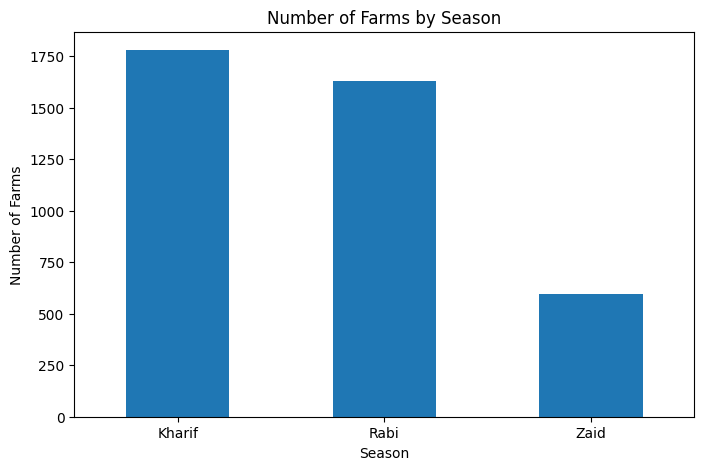

In [7]:
print("Number of Farms by Season:")
season_count = df["Season"].value_counts()
print(season_count)

plt.figure(figsize=(8, 5))
season_count.plot(kind="bar")
plt.title("Number of Farms by Season")
plt.xlabel("Season")
plt.ylabel("Number of Farms")
plt.xticks(rotation=0)
plt.show()

Number of Farms by Crop:
Crop
Rice         690
Wheat        614
Maize        551
Cotton       508
Pulses       496
Groundnut    424
Chilli       412
Sugarcane    305
Name: count, dtype: int64


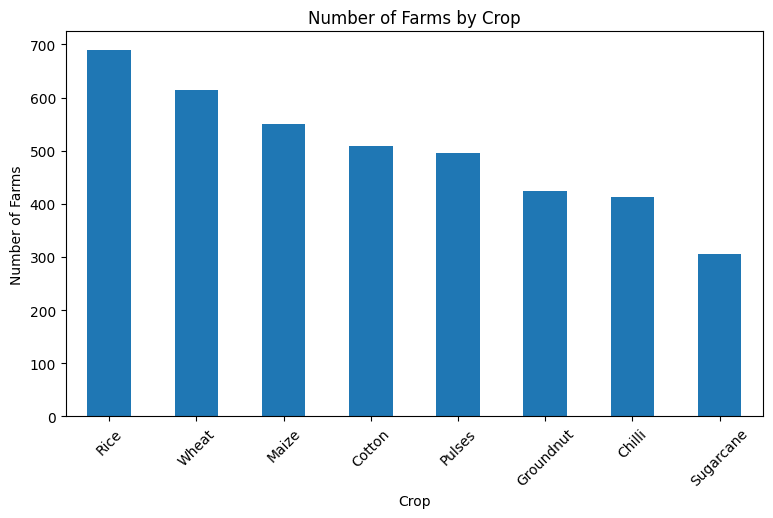

In [8]:
crop_count = df["Crop"].value_counts()

print("Number of Farms by Crop:")
print(crop_count)

plt.figure(figsize=(9, 5))
crop_count.plot(kind="bar")
plt.title("Number of Farms by Crop")
plt.xlabel("Crop")
plt.ylabel("Number of Farms")
plt.xticks(rotation=45)
plt.show()

Yield related columns:
['Yield_Tonnes_Ha']
Average Yield by Season:
Season
Kharif    5.628612
Rabi      5.039435
Zaid      4.641313
Name: Yield_Tonnes_Ha, dtype: float64


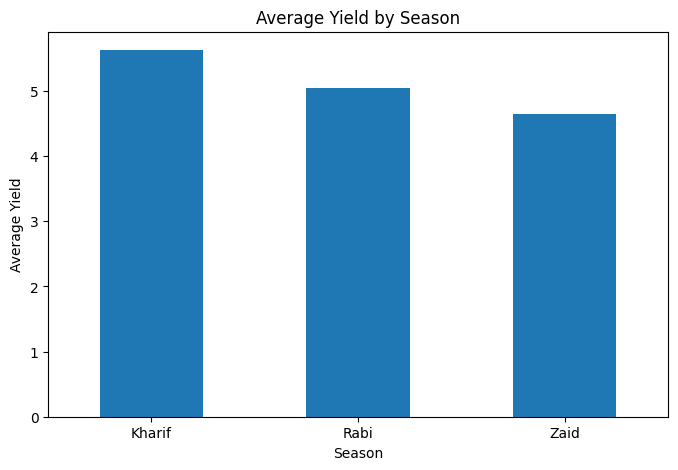

In [11]:
yield_columns = [col for col in df.columns if "yield" in col.lower()]

print("Yield related columns:")
print(yield_columns)

if len(yield_columns) > 0:
    yield_col = yield_columns[0]

    season_yield = df.groupby("Season")[yield_col].mean().sort_values(ascending=False)

    print("Average Yield by Season:")
    print(season_yield)

    plt.figure(figsize=(8, 5))
    season_yield.plot(kind="bar")
    plt.title("Average Yield by Season")
    plt.xlabel("Season")
    plt.ylabel("Average Yield")
    plt.xticks(rotation=0)
    plt.show()
else:
    print("Yield column not found in dataset")

Average Yield by Crop:
Crop
Sugarcane    46.642361
Maize         2.710036
Rice          2.431304
Wheat         2.108013
Chilli        1.542767
Groundnut     1.322901
Cotton        1.229783
Pulses        0.921512
Name: Yield_Tonnes_Ha, dtype: float64


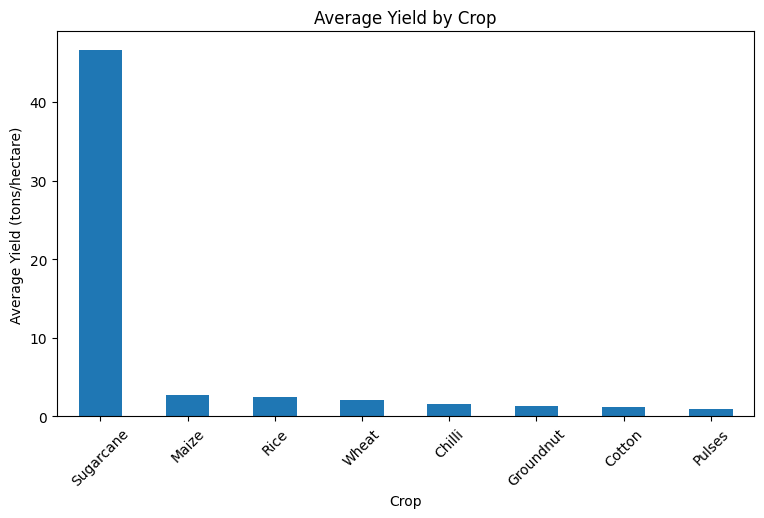

In [12]:
crop_yield = df.groupby("Crop")["Yield_Tonnes_Ha"].mean().sort_values(ascending=False)

print("Average Yield by Crop:")
print(crop_yield)

plt.figure(figsize=(9, 5))
crop_yield.plot(kind="bar")
plt.title("Average Yield by Crop")
plt.xlabel("Crop")
plt.ylabel("Average Yield (tons/hectare)")
plt.xticks(rotation=45)
plt.show()

Average Yield by Season and Crop:


Crop,Chilli,Cotton,Groundnut,Maize,Pulses,Rice,Sugarcane,Wheat
Season,,,,,,,,
Kharif,1.731459,1.374512,1.484974,2.966410,1.036063,2.698376,53.459120,2.253664
Rabi,1.465031,1.198358,1.233164,2.603648,0.875962,2.322847,43.286124,2.057468
Zaid,1.195312,0.960217,1.037778,2.290952,0.669677,1.900490,38.423922,1.748588


<Figure size 1200x600 with 0 Axes>

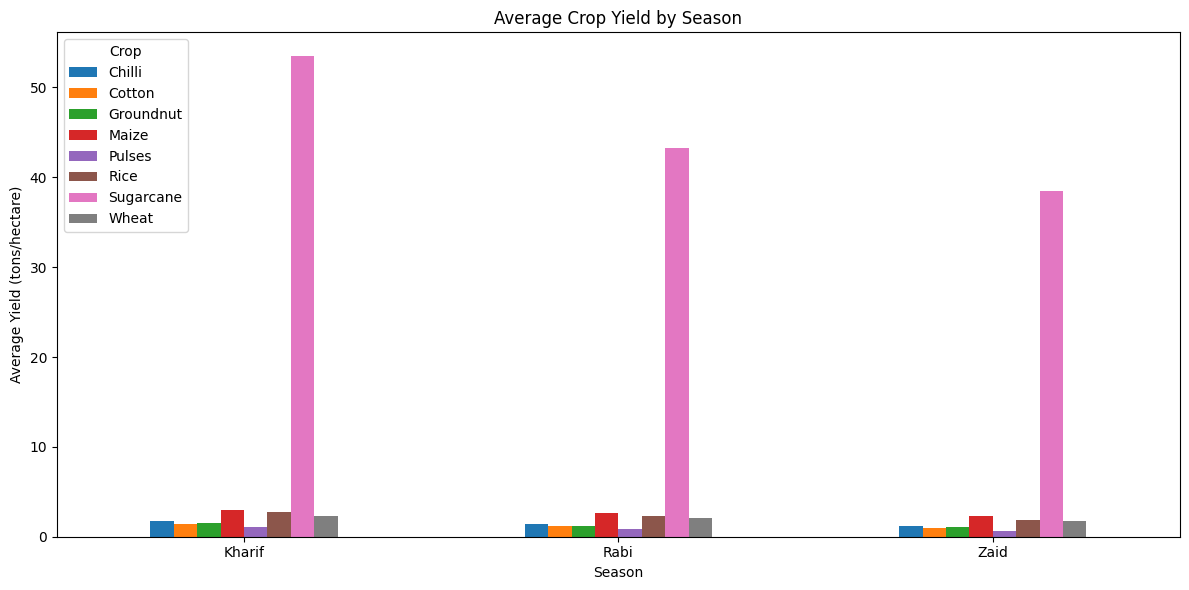

In [13]:
season_crop_yield = df.groupby(["Season", "Crop"])["Yield_Tonnes_Ha"].mean().unstack()

print("Average Yield by Season and Crop:")
display(season_crop_yield)

plt.figure(figsize=(12, 6))
season_crop_yield.plot(kind="bar", figsize=(12, 6))

plt.title("Average Crop Yield by Season")
plt.xlabel("Season")
plt.ylabel("Average Yield (tons/hectare)")
plt.xticks(rotation=0)
plt.legend(title="Crop")
plt.tight_layout()
plt.show()

Average Rainfall and Yield by Season:


,Rainfall_mm,Yield_Tonnes_Ha
Season,,
Kharif,849.199663,5.628612
Rabi,437.615366,5.039435
Zaid,304.654714,4.641313


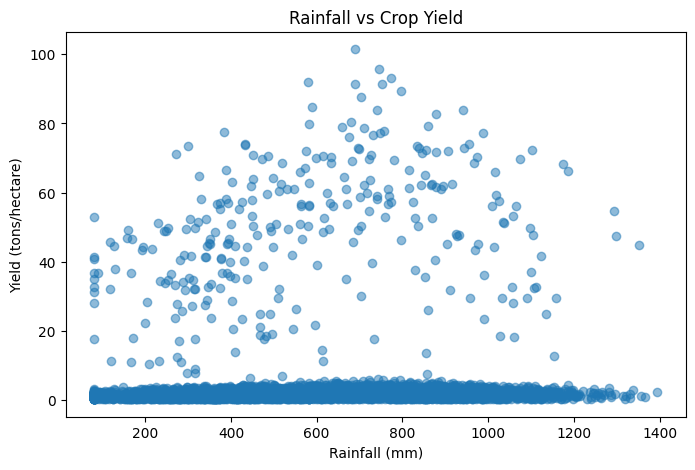

In [14]:
rainfall_yield = df.groupby("Season")[["Rainfall_mm", "Yield_Tonnes_Ha"]].mean()

print("Average Rainfall and Yield by Season:")
display(rainfall_yield)

plt.figure(figsize=(8, 5))
plt.scatter(df["Rainfall_mm"], df["Yield_Tonnes_Ha"], alpha=0.5)

plt.title("Rainfall vs Crop Yield")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (tons/hectare)")
plt.show()

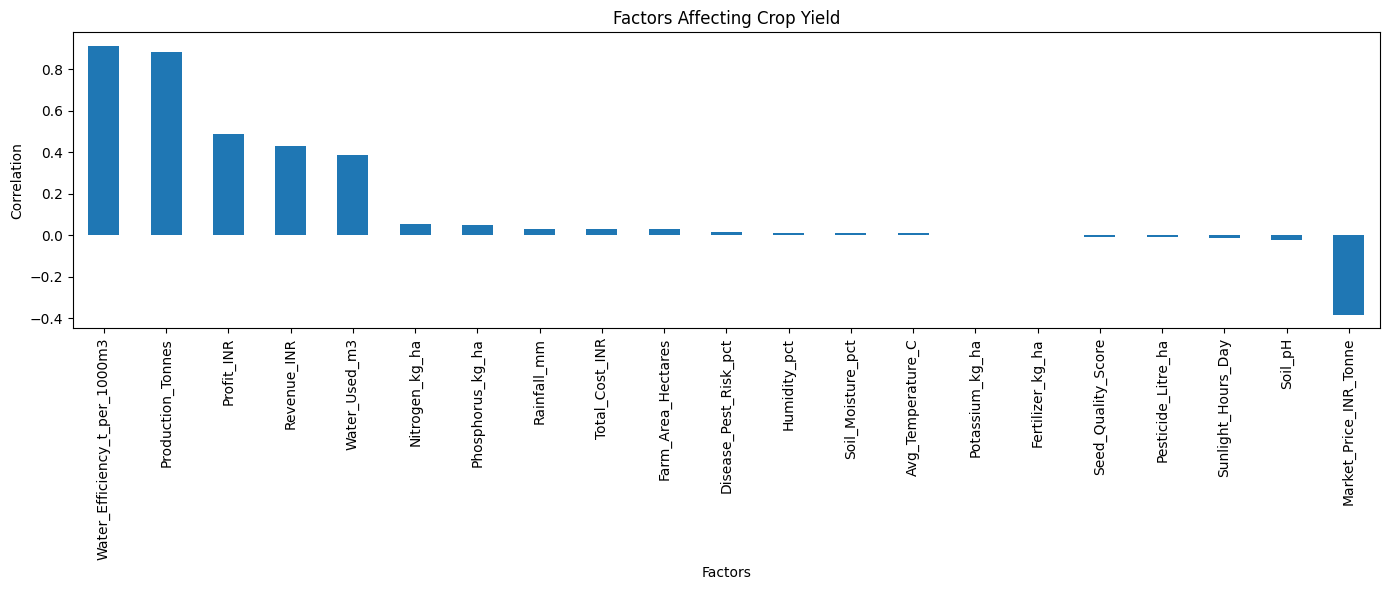

In [16]:
numeric_df = df.select_dtypes(include="number")

correlation = numeric_df.corr()["Yield_Tonnes_Ha"].drop("Yield_Tonnes_Ha")
correlation = correlation.sort_values(ascending=False)

plt.figure(figsize=(14, 6))
correlation.plot(kind="bar")

plt.title("Factors Affecting Crop Yield")
plt.xlabel("Factors")
plt.ylabel("Correlation")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

Top 10 Factors Affecting Yield:
Water_Efficiency_t_per_1000m3    0.912568
Production_Tonnes                0.882813
Profit_INR                       0.488466
Revenue_INR                      0.432152
Water_Used_m3                    0.386294
Market_Price_INR_Tonne           0.382607
Nitrogen_kg_ha                   0.053149
Phosphorus_kg_ha                 0.047941
Rainfall_mm                      0.030951
Total_Cost_INR                   0.030622
Name: Yield_Tonnes_Ha, dtype: float64


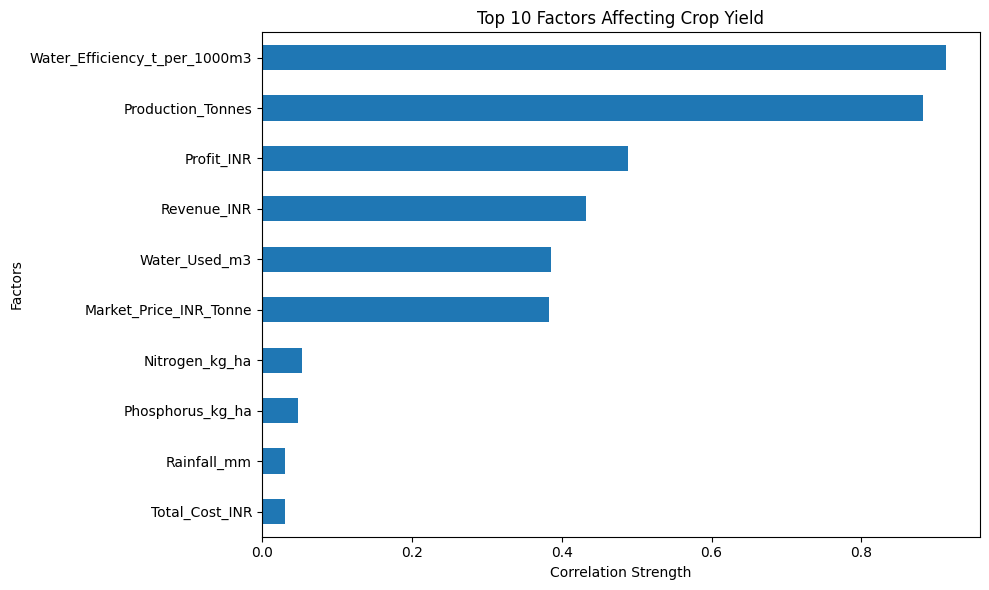

In [17]:
top_factors = correlation.abs().sort_values(ascending=False).head(10)

print("Top 10 Factors Affecting Yield:")
print(top_factors)

plt.figure(figsize=(10, 6))
top_factors.sort_values().plot(kind="barh")

plt.title("Top 10 Factors Affecting Crop Yield")
plt.xlabel("Correlation Strength")
plt.ylabel("Factors")

plt.tight_layout()
plt.show()

Average Yield by State:
State
Punjab            6.121116
Karnataka         5.685481
Gujarat           5.659016
Telangana         5.044477
Maharashtra       5.017480
Madhya Pradesh    4.989940
Tamil Nadu        4.875175
Andhra Pradesh    4.628771
Name: Yield_Tonnes_Ha, dtype: float64


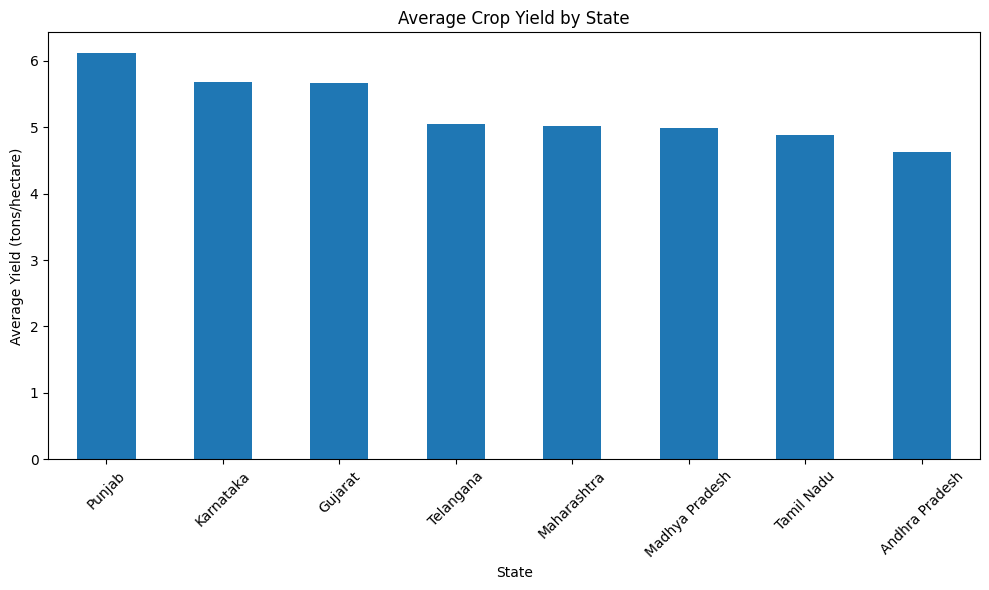

In [18]:
state_yield = df.groupby("State")["Yield_Tonnes_Ha"].mean().sort_values(ascending=False)

print("Average Yield by State:")
print(state_yield)

plt.figure(figsize=(10, 6))
state_yield.plot(kind="bar")

plt.title("Average Crop Yield by State")
plt.xlabel("State")
plt.ylabel("Average Yield (tons/hectare)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Average Yield by District:
District
Rajkot      6.020150
Nalgonda    5.801181
Ludhiana    5.799883
Warangal    5.503389
Guntur      5.472359
Raichur     4.940777
Indore      4.883240
Nashik      4.863881
Krishna     4.847583
Erode       4.177816
Name: Yield_Tonnes_Ha, dtype: float64


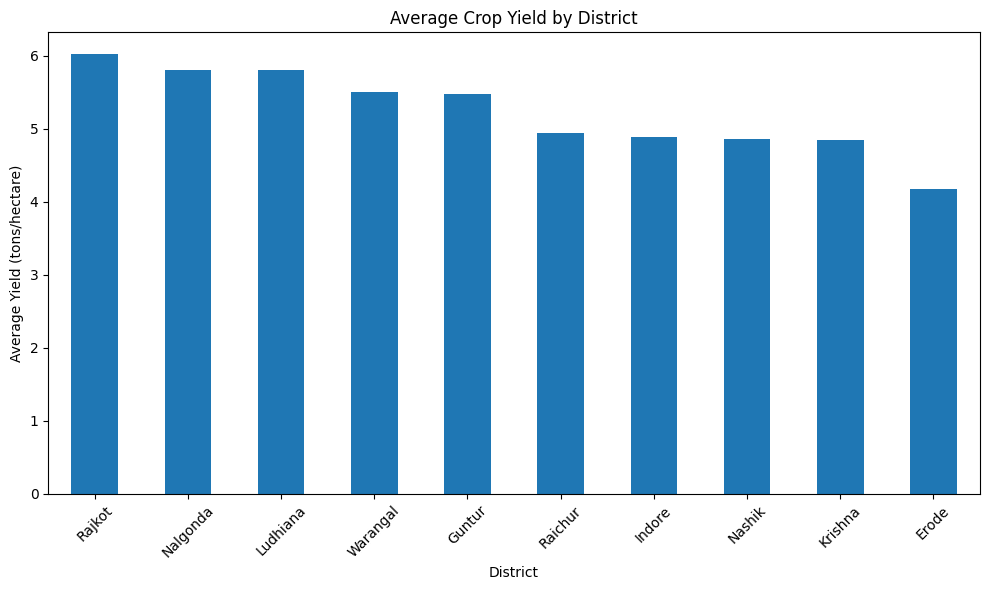

In [19]:
district_yield = df.groupby("District")["Yield_Tonnes_Ha"].mean().sort_values(ascending=False)

print("Average Yield by District:")
print(district_yield)

plt.figure(figsize=(10, 6))
district_yield.plot(kind="bar")

plt.title("Average Crop Yield by District")
plt.xlabel("District")
plt.ylabel("Average Yield (tons/hectare)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [21]:
irrigation_columns = [col for col in df.columns if "irrig" in col.lower()]

print("Irrigation Related Columns:")
print(irrigation_columns)

Irrigation Related Columns:
['Irrigation_Method']


Average Yield by Irrigation Method:
Irrigation_Method
Drip         6.577989
Sprinkler    5.160627
Flood        4.863977
Rainfed      4.602142
Name: Yield_Tonnes_Ha, dtype: float64


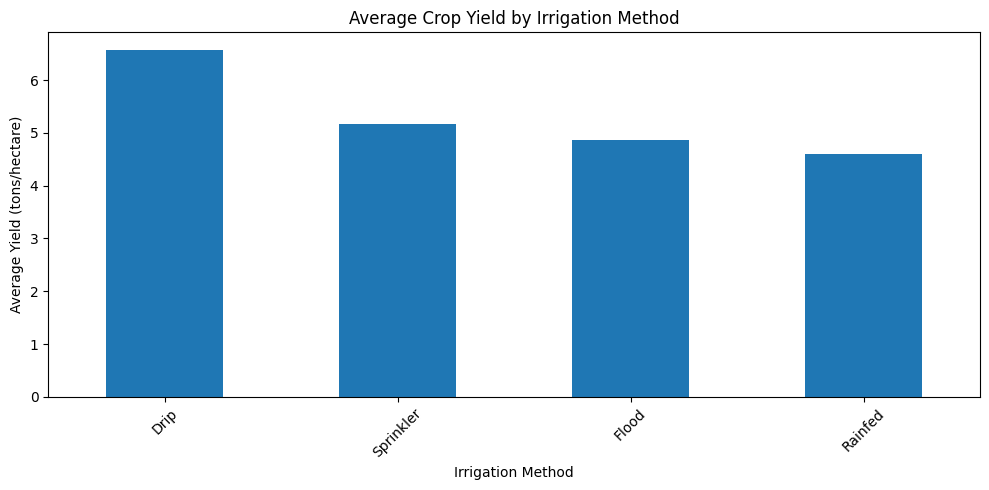

In [22]:
irrigation_yield = df.groupby("Irrigation_Method")["Yield_Tonnes_Ha"].mean().sort_values(ascending=False)

print("Average Yield by Irrigation Method:")
print(irrigation_yield)

plt.figure(figsize=(10, 5))
irrigation_yield.plot(kind="bar")

plt.title("Average Crop Yield by Irrigation Method")
plt.xlabel("Irrigation Method")
plt.ylabel("Average Yield (tons/hectare)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [23]:
fertilizer_columns = [col for col in df.columns if "fertil" in col.lower()]

print("Fertilizer Related Columns:")
print(fertilizer_columns)

Fertilizer Related Columns:
['Fertilizer_kg_ha']


In [24]:
crop_state_yield = df.groupby(["State", "Crop"])["Yield_Tonnes_Ha"].mean().sort_values(ascending=False)

print("Top 10 State-Crop Combinations by Average Yield:")
print(crop_state_yield.head(10))

Top 10 State-Crop Combinations by Average Yield:
State           Crop     
Andhra Pradesh  Sugarcane    50.263548
Tamil Nadu      Sugarcane    49.621290
Madhya Pradesh  Sugarcane    47.480000
Gujarat         Sugarcane    47.061190
Maharashtra     Sugarcane    46.961944
Telangana       Sugarcane    46.465278
Punjab          Sugarcane    44.232449
Karnataka       Sugarcane    43.563333
Punjab          Maize         2.909825
Tamil Nadu      Maize         2.806479
Name: Yield_Tonnes_Ha, dtype: float64


Average Yield by Fertilizer Usage:
Fertilizer_kg_ha
48.3     93.13
297.2    91.46
339.2    91.32
117.2    82.68
91.3     80.36
102.8    72.80
296.0    72.32
158.0    70.83
310.4    69.71
122.5    69.39
Name: Yield_Tonnes_Ha, dtype: float64


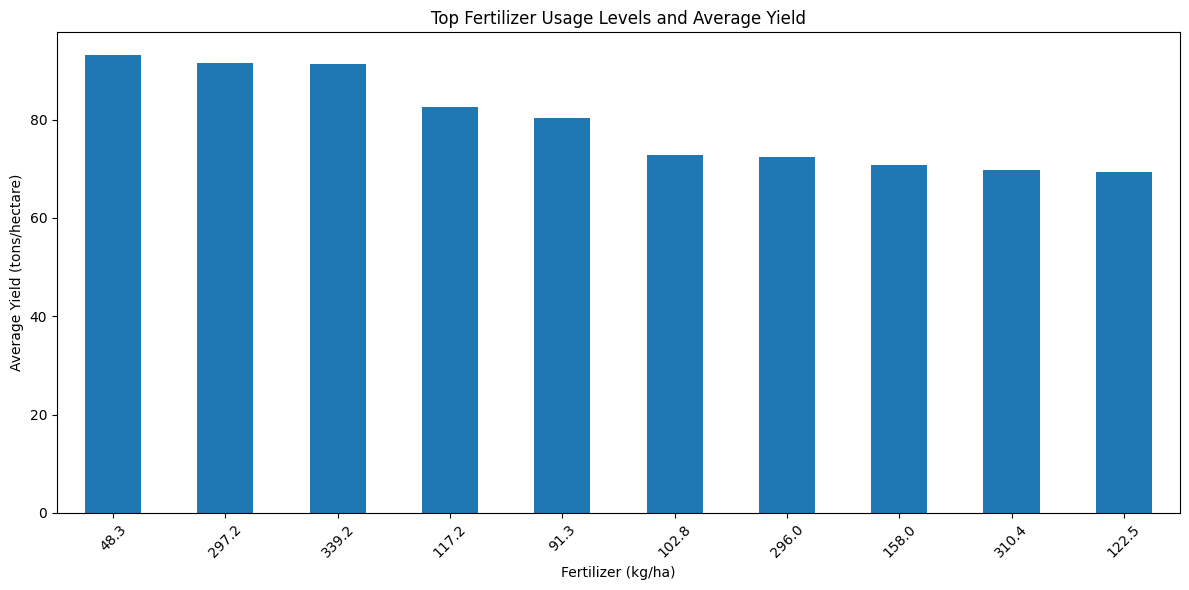

In [28]:
fertilizer_yield = df.groupby("Fertilizer_kg_ha")["Yield_Tonnes_Ha"].mean().sort_values(ascending=False)

print("Average Yield by Fertilizer Usage:")
print(fertilizer_yield.head(10))

plt.figure(figsize=(12, 6))
fertilizer_yield.head(10).plot(kind="bar")

plt.title("Top Fertilizer Usage Levels and Average Yield")
plt.xlabel("Fertilizer (kg/ha)")
plt.ylabel("Average Yield (tons/hectare)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [29]:
pesticide_columns = [col for col in df.columns if "pesticide" in col.lower()]

print("Pesticide Related Columns:")
print(pesticide_columns)

Pesticide Related Columns:
['Pesticide_Litre_ha']


Using Column: Pesticide_Litre_ha

Average Yield by Pesticide Usage:
Pesticide_Litre_ha
0.73     72.5400
8.66     70.6200
8.75     63.1900
12.08    57.2600
1.75     57.0400
3.56     42.2950
10.07    38.9700
9.09     36.8700
4.56     36.3125
1.70     34.7800
Name: Yield_Tonnes_Ha, dtype: float64


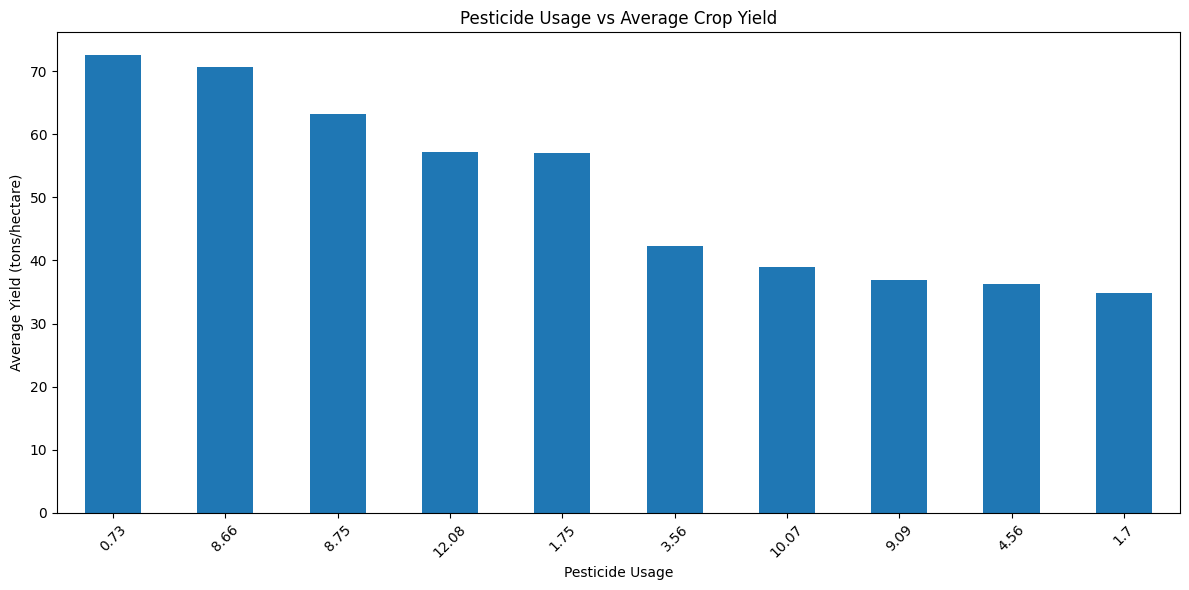

In [30]:
if len(pesticide_columns) > 0:
    pesticide_col = pesticide_columns[0]

    print("Using Column:", pesticide_col)

    pesticide_yield = df.groupby(pesticide_col)["Yield_Tonnes_Ha"].mean().sort_values(ascending=False)

    print("\nAverage Yield by Pesticide Usage:")
    print(pesticide_yield.head(10))

    plt.figure(figsize=(12, 6))
    pesticide_yield.head(10).plot(kind="bar")

    plt.title("Pesticide Usage vs Average Crop Yield")
    plt.xlabel("Pesticide Usage")
    plt.ylabel("Average Yield (tons/hectare)")
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()
else:
    print("No pesticide-related column found.")

Best Performing Crop: Sugarcane
Average Yield: 46.64 tons/hectare


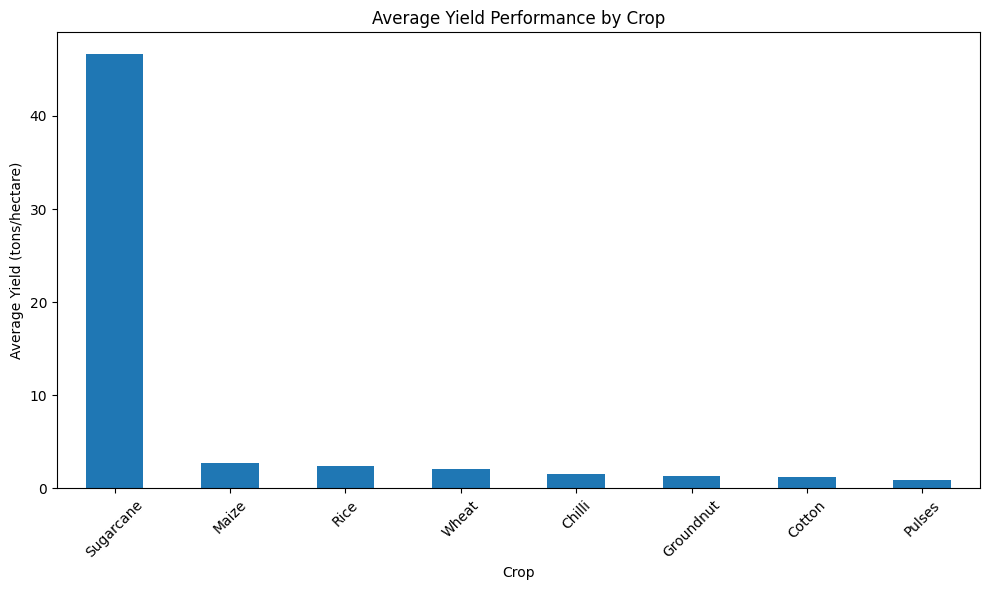

In [31]:
crop_performance = df.groupby("Crop")["Yield_Tonnes_Ha"].mean().sort_values(ascending=False)

best_crop = crop_performance.index[0]
best_crop_yield = crop_performance.iloc[0]

print("Best Performing Crop:", best_crop)
print("Average Yield:", round(best_crop_yield, 2), "tons/hectare")

plt.figure(figsize=(10, 6))
crop_performance.plot(kind="bar")

plt.title("Average Yield Performance by Crop")
plt.xlabel("Crop")
plt.ylabel("Average Yield (tons/hectare)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Best Performing Season: Kharif
Average Yield: 5.63 tons/hectare


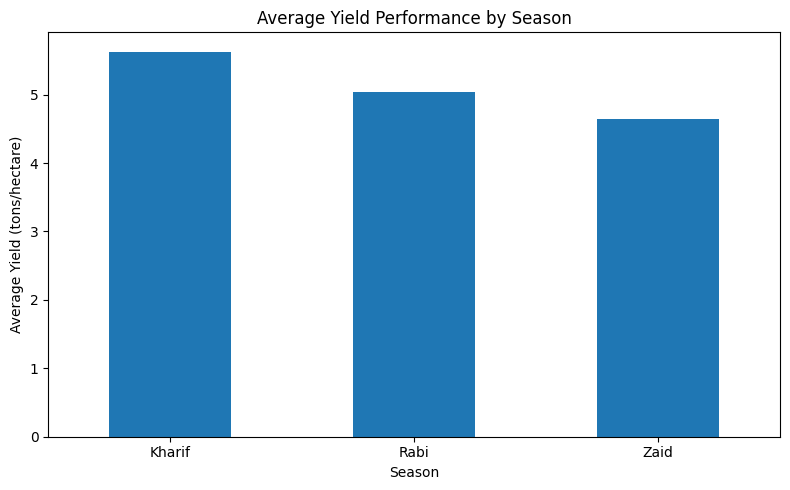

In [32]:
season_performance = df.groupby("Season")["Yield_Tonnes_Ha"].mean().sort_values(ascending=False)

best_season = season_performance.index[0]
best_season_yield = season_performance.iloc[0]

print("Best Performing Season:", best_season)
print("Average Yield:", round(best_season_yield, 2), "tons/hectare")

plt.figure(figsize=(8, 5))
season_performance.plot(kind="bar")

plt.title("Average Yield Performance by Season")
plt.xlabel("Season")
plt.ylabel("Average Yield (tons/hectare)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [33]:
print("KEY FINDINGS")
print("============")

print("Highest Yield Crop:", best_crop)
print("Highest Yield Season:", best_season)

print("\nTop 5 Crops by Average Yield:")
print(crop_performance.head(5))

print("\nTop 5 States by Average Yield:")
print(state_yield.head(5))

print("\nTop 5 Districts by Average Yield:")
print(district_yield.head(5))

KEY FINDINGS
Highest Yield Crop: Sugarcane
Highest Yield Season: Kharif

Top 5 Crops by Average Yield:
Crop
Sugarcane    46.642361
Maize         2.710036
Rice          2.431304
Wheat         2.108013
Chilli        1.542767
Name: Yield_Tonnes_Ha, dtype: float64

Top 5 States by Average Yield:
State
Punjab         6.121116
Karnataka      5.685481
Gujarat        5.659016
Telangana      5.044477
Maharashtra    5.017480
Name: Yield_Tonnes_Ha, dtype: float64

Top 5 Districts by Average Yield:
District
Rajkot      6.020150
Nalgonda    5.801181
Ludhiana    5.799883
Warangal    5.503389
Guntur      5.472359
Name: Yield_Tonnes_Ha, dtype: float64


In [34]:
print("PROJECT CONCLUSION")
print("==================")

print("This project analyzed seasonal agriculture performance using crop,")
print("season, rainfall, fertilizer, pesticide and regional data.")

print("\nKey conclusions:")
print("1. Sugarcane has the highest average crop yield.")
print("2. Kharif is the highest-performing season based on average yield.")
print("3. Punjab has the highest average yield among the analyzed states.")
print("4. Rajkot has the highest average yield among the analyzed districts.")
print("5. Agricultural inputs and environmental factors show differences in crop performance.")
print("6. The analysis can help identify better-performing crops, seasons and regions.")

PROJECT CONCLUSION
This project analyzed seasonal agriculture performance using crop,
season, rainfall, fertilizer, pesticide and regional data.

Key conclusions:
1. Sugarcane has the highest average crop yield.
2. Kharif is the highest-performing season based on average yield.
3. Punjab has the highest average yield among the analyzed states.
4. Rajkot has the highest average yield among the analyzed districts.
5. Agricultural inputs and environmental factors show differences in crop performance.
6. The analysis can help identify better-performing crops, seasons and regions.
